# Evaluating a RAG Pipeline, Component by Component

**Philosopher Chat** is a retrieval-augmented chatbot grounded in 12 public-domain philosophy texts (~5,700 chunks). This notebook measures the contribution of each retrieval component with four **RAGAS** metrics — an incremental ablation:

1. **Baseline (Hybrid)** — dense (EmbeddingGemma) + BM25, fused with Reciprocal Rank Fusion
2. **+ Reranker** — adds a `BGE-reranker-v2-m3` cross-encoder over the candidate pool
3. **+ Query Rewrite** — adds multi-query expansion (LLM paraphrases, fused before reranking)

> *Question: does each added component actually move the metrics — or is it complexity for its own sake?*

Same 12 questions with reference answers, scored by an LLM judge (Claude Haiku 4.5). Pipeline + sample generation in [`evaluate.py`](../evaluate.py).

## The four metrics (RAGAS definitions)

| Metric | Question it answers | What it catches |
|---|---|---|
| **Faithfulness** | Are the answer's claims supported by the retrieved context? | Hallucination |
| **Answer Relevancy** | Does the answer actually address the question? | Off-topic / evasive answers |
| **Context Precision** | Are the *relevant* chunks ranked near the top? | Retrieval ordering quality |
| **Context Recall** | Does the context cover the reference answer? | Missing evidence |

Faithfulness and Answer Relevancy assess the **generation**; Context Precision and Recall assess the **retrieval** directly. Metrics follow the [**RAGAS**](https://docs.ragas.io) definitions, scored by an LLM-as-judge.

In [1]:
import json
from pathlib import Path
import pandas as pd

results = json.loads(Path("../eval_results.json").read_text(encoding="utf-8"))
meta = results["metadata"]
print(f"Framework        : {meta.get('framework')}")
print(f"Judge model      : {meta['judge_model']}")
print(f"Generation model : {meta['gen_model']}")
print(f"Reranker         : {meta['reranker_model']}")
print(f"Questions        : {meta['n_questions']}  (x{len(results['configs'])} configs)")

Framework        : RAGAS metrics — Claude Haiku 4.5 judge
Judge model      : claude-haiku-4-5
Generation model : Gemma 4 MoE 26B  [Google]
Reranker         : BAAI/bge-reranker-v2-m3
Questions        : 12  (x3 configs)


## Aggregate results — incremental ablation

In [2]:
labels = {
    "faithfulness": "Faithfulness",
    "answer_relevancy": "Answer Relevancy",
    "context_precision": "Context Precision",
    "context_recall": "Context Recall",
}
configs = list(results["configs"].keys())

df = pd.DataFrame(results["configs"]).T[list(labels)].rename(columns=labels)
df.loc["\u0394 (full vs baseline)"] = [results["deltas"][m] for m in labels]
df.round(3)

,Faithfulness,Answer Relevancy,Context Precision,Context Recall
Baseline (Hybrid),0.399,0.942,1.000,0.375
+ Reranker,0.435,0.900,1.000,0.514
+ Query Rewrite,0.431,0.912,0.994,0.431
Δ (full vs baseline),0.033,-0.029,-0.006,0.056


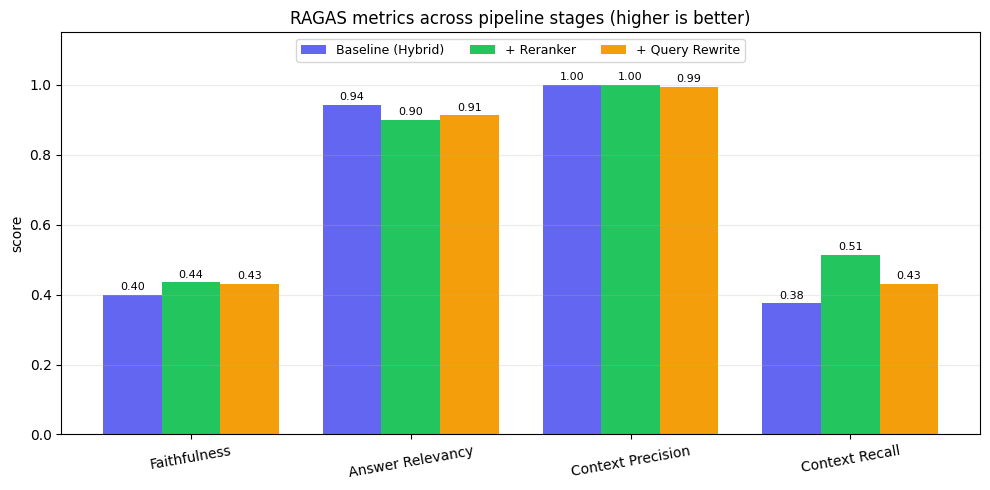

In [3]:
import matplotlib.pyplot as plt
import numpy as np

metrics = list(labels)
names = [labels[m] for m in metrics]
x = np.arange(len(metrics))
colors = ["#6366F1", "#22C55E", "#F59E0B"]
w = 0.8 / len(configs)

fig, ax = plt.subplots(figsize=(10, 5))
for i, cfg in enumerate(configs):
    bars = ax.bar(x + (i - (len(configs)-1)/2) * w,
                  [results["configs"][cfg][m] for m in metrics], w,
                  label=cfg, color=colors[i % len(colors)])
    ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8)
ax.set_xticks(x, names, rotation=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel("score")
ax.set_title("RAGAS metrics across pipeline stages (higher is better)")
ax.legend(loc="upper center", ncol=3, fontsize=9)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Per-question breakdown

Where does the reranker's recall gain come from? Context Recall per question, baseline vs. + Reranker.

In [4]:
base, rer = configs[0], configs[1]
rows = []
for r0, r1 in zip(results["per_question"][base], results["per_question"][rer]):
    rows.append({
        "question": r0["question"][:46],
        "Faith (base)": r0["faithfulness"], "Faith (+rerank)": r1["faithfulness"],
        "Recall (base)": r0["context_recall"], "Recall (+rerank)": r1["context_recall"],
    })
pd.DataFrame(rows).set_index("question").round(2)

,Faith (base),Faith (+rerank),Recall (base),Recall (+rerank)
question,,,,
What does Nietzsche mean by the death of God?,0.46,0.12,0.0,0.00
How does Schopenhauer view suffering and the w,0.21,0.24,0.0,0.67
What is Hume's argument about causation?,0.42,0.44,0.5,0.50
Can we have certain knowledge of the external,0.55,0.50,1.0,1.00
What is Kant's categorical imperative?,0.58,0.62,0.5,0.50
How does Mill justify the principle of utility,0.43,0.57,0.0,0.50
What does Marcus Aurelius advise about things,0.18,0.70,0.0,0.00
What is Epictetus's distinction between what i,0.44,0.65,1.0,1.00
What is Plato's ideal society in The Republic?,0.26,0.21,0.0,0.00


## Findings

The ablation gives a clear, **non-obvious** answer — read the numbers in the table above, not intuition:

| Metric | Baseline | + Reranker | + Query Rewrite |
|---|---|---|---|
| Faithfulness | 0.40 | **0.44** | 0.43 |
| Answer Relevancy | 0.94 | 0.90 | 0.91 |
| Context Precision | 1.00 | 1.00 | 0.99 |
| Context Recall | 0.38 | **0.51** | 0.43 |

- **The reranker is the clear win.** Context Recall jumps **+0.14 (0.38 → 0.51)** and Faithfulness rises (0.40 → 0.44), with no meaningful cost to precision or relevancy. On a corpus that ships with translator commentary *about* the philosophers, the cross-encoder demotes that noise and surfaces primary-source passages — so more of the reference answer is actually covered.
- **Query rewriting did *not* help here — it slightly hurt.** Adding multi-query expansion on top of the reranker *reduced* Context Recall (0.51 → 0.43) and nudged Answer Relevancy/Precision down. The extra paraphrases pulled broader-but-less-on-target chunks into the fused pool, diluting the reranker's gains on this small, focused corpus.
- **This is the whole reason to evaluate.** "More components = better" is a tempting assumption; the data refuses it. The honest engineering call is to **ship the reranker and treat query rewriting as corpus-dependent** (it tends to pay off on larger, noisier corpora and vaguer queries — not this one).
- **Absolute Faithfulness/Recall look modest (0.4–0.5)** because these are dense, multi-claim philosophy answers judged against only 6 retrieved chunks — many valid claims aren't in the window. The *relative* comparison across configs is the signal.

### Takeaway
Each component was **measured, not assumed**. The reranker earns its place on the metrics; query rewriting, on this corpus, does not — exactly the discipline modern RAG guides call for: *don't add complexity without validating that the metrics move in the right direction on your actual data.*

_Note: scores come from an LLM judge and carry judge variance; treat them as directional, and lean on the per-question breakdown and the size of each gap rather than any single decimal._